In [163]:
from pathlib import Path
import re, os, sys
import numpy as np
import matplotlib.pyplot as plt
import importlib
import roicat
from functools import reduce

import roi_tracking_helpers
importlib.reload(roi_tracking_helpers)
# from roi_tracking_helpers import roicat_align_rois, roicat_visualize_tracked_rois


<module 'roi_tracking_helpers' from '/Users/athinaapostolelli/Documents/SWC/VR_ABCD_project/VR_ABCD/roicat/roi_tracking_helpers.py'>

In [ ]:
# Define paths and basic variables
basepath = Path('/Volumes/mrsic_flogel/public/projects/AtApSuKuSaRe_20250129_HFScohort2')
animal = 'TAA0000066'
roicat_data_name = animal 
roicat_dir = Path(f'/Volumes/mrsic_flogel/public/projects/AtApSuKuSaRe_20250129_HFScohort2/{roicat_data_name}/ROICaT')

# Choose sessions and paths for alignment
sessions_to_align = ['ses-005_date-20250218_protocol-t0',
    'ses-006_date-20250224_protocol-t1',
    'ses-007_date-20250304_protocol-t2',
    'ses-008_date-20250306_protocol-t3',
    'ses-010_date-20250314_protocol-t4',
    'ses-011_date-20250315_protocol-t5',
    'ses-012_date-20250318_protocol-t6',
    'ses-013_date-20250320_protocol-t7',
    'ses-014_date-20250326_protocol-t8',
    'ses-015_date-20250327_protocol-t9',
    'ses-016_date-20250330_protocol-t10',
    'ses-017_date-20250331_protocol-t11',
    'ses-018_date-20250403_protocol-t12',
    'ses-019_date-20250404_protocol-t13',
    'ses-020_date-20250412_protocol-t14',
    'ses-021_date-20250426_protocol-t15',
    'ses-022_date-20250509_protocol-t16',
    'ses-023_date-20250516_protocol-t17']

protocol_nums = [int(re.search(r'protocol-t(\d+)', s).group(1)) for s in sessions_to_align]
protocol_nums = [protocol_nums[0], protocol_nums[-1]]

num_sessions = len(sessions_to_align)

alignment_dir = roicat_dir / 'alignment' / '_'.join(f't{n}' for n in protocol_nums)
print(alignment_dir)

/Volumes/mrsic_flogel/public/projects/AtApSuKuSaRe_20250129_HFScohort2/TAA0000066/ROICaT/alignment/t0_t17


In [ ]:
# Load ROICaT results
results = roi_tracking_helpers.load_roicat_results(roicat_dir, roicat_data_name)

In [ ]:
# Get number of (valid) cells per session 
num_valid_neurons, num_neurons = roi_tracking_helpers.get_neuron_count(basepath, animal, sessions_to_align)
print(num_valid_neurons, num_neurons)

Loading iscell data for session ses-005_date-20250218_protocol-t0
Loading iscell data for session ses-006_date-20250224_protocol-t1
Loading iscell data for session ses-007_date-20250304_protocol-t2
Loading iscell data for session ses-008_date-20250306_protocol-t3
Loading iscell data for session ses-010_date-20250314_protocol-t4
Loading iscell data for session ses-011_date-20250315_protocol-t5
Loading iscell data for session ses-012_date-20250318_protocol-t6
Loading iscell data for session ses-013_date-20250320_protocol-t7
Loading iscell data for session ses-014_date-20250326_protocol-t8
Loading iscell data for session ses-015_date-20250327_protocol-t9
Loading iscell data for session ses-016_date-20250330_protocol-t10
Loading iscell data for session ses-017_date-20250331_protocol-t11
Loading iscell data for session ses-018_date-20250403_protocol-t12
Loading iscell data for session ses-019_date-20250404_protocol-t13
Loading iscell data for session ses-020_date-20250412_protocol-t14
Loadi

#### Visualize ROICaT output


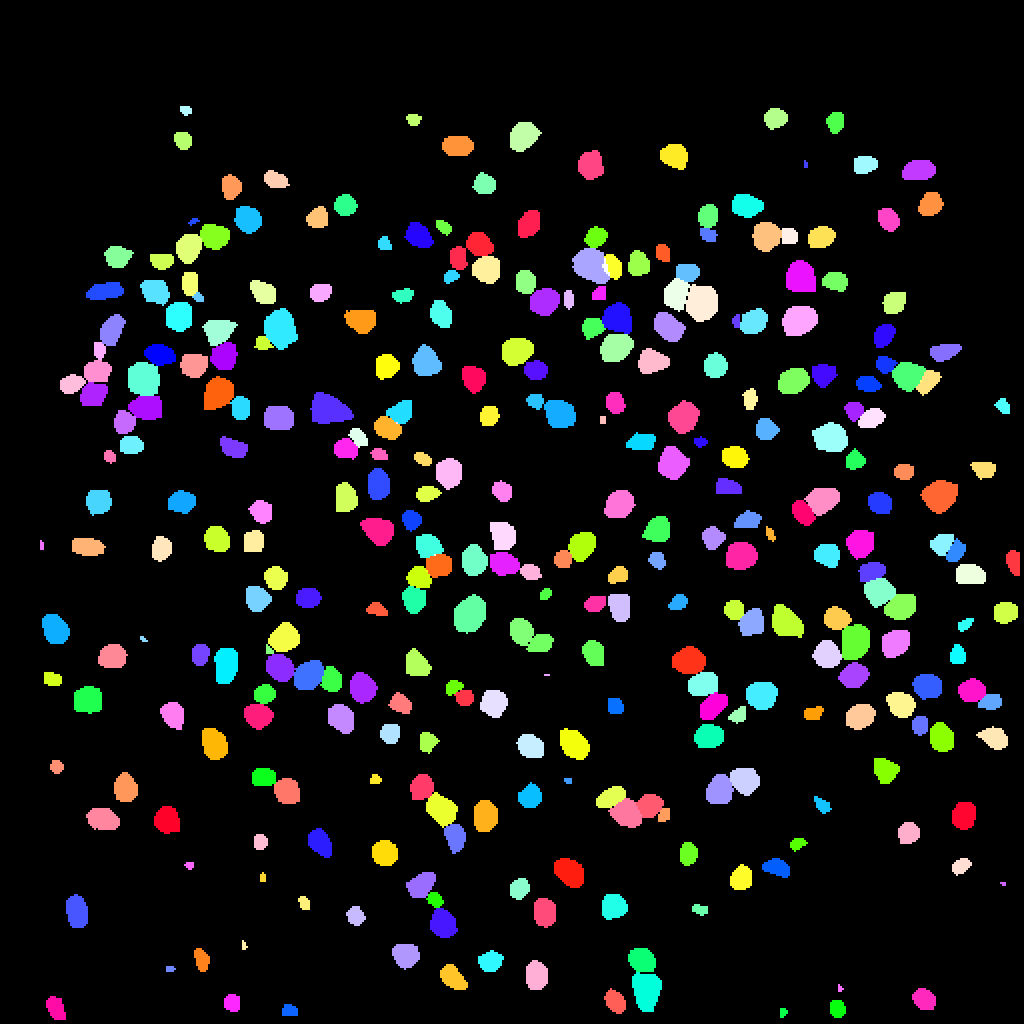

In [165]:
# Visualize ROICaT output 
roi_tracking_helpers.visualize_output(results, dir_save=roicat_dir, plot_metrics=False, \
                                      plot_clusters=False, plot_aligned_tracked_clusters=True)

#### Align clusters across sessions
After running ROICaT tracking, we are left with outputs we call 'labels' / 'UCIDs' (unique cluster IDs). These are unique integer ID numbers assigned that describe which cluster each ROI corresponds to across all sessions. Non-negative labels describe unique clusters, while '-1' specifically describes unclustered ROIs.

After alignment, we can extract idx_original_aligned with shape: (n_sessions, n_tracked_neurons). The **index** of an element for each row (session) in this array is the ROICaT tracking index / 'label' / 'UCID'. The **value** of that element corresponds to the suite2p label. We can thus use this value to directly extract the neural data for specific neurons from the suite2p output. 

In [ ]:
# Load neural data (suite2p processed) - NOTE: might take ~1h to load depending on the computer
# data = roi_tracking_helpers.load_neural_data(basepath, animal, sessions_to_align, data_type='F')

In [ ]:
# Align the neural data and the cluster IDs or load the data if already aligned
_, idx_original_aligned = roi_tracking_helpers.align_rois(roicat_dir, roicat_data_name, sessions_to_align, \
                                                          basepath, animal, alignment_method='F', neural_data=None, \
                                                          roicat_results=results, plot_alignment=True, save_results=True, force_reload=False,\
                                                          alignment_dir=alignment_dir, filename=f'roicat_aligned_ROIs_{'_'.join(['t' + str(n) for n in protocol_nums])}.npy')

Aligned clusters already found. Loading...


#### Find number of neurons tracked across sessions

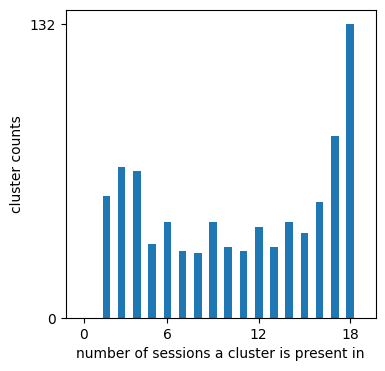

In [130]:
# Cluster persistence = how many session a cluster is present in
fig = roi_tracking_helpers.visualize_cluster_persistence(results)
fig.savefig(os.path.join(alignment_dir, 'cluster_persistence.png'))

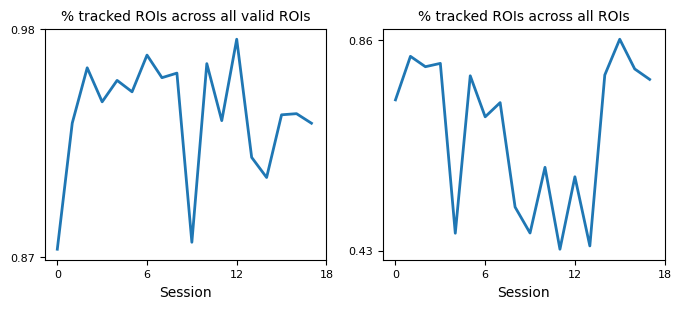

In [149]:
# Get the number of tracked clusters over all (valid) clusters per session 
fig = roi_tracking_helpers.visualize_tracked_clusters_per_session(idx_original_aligned, num_valid_neurons, num_neurons)
fig.savefig(os.path.join(alignment_dir, 'clusters_tracked_per_session.png'))

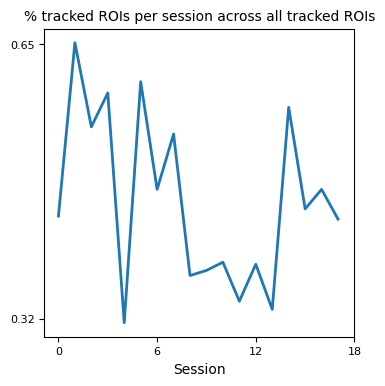

In [150]:
# Get the number of tracked clusters per session over all tracked clusters 
fig = roi_tracking_helpers.visualize_tracked_clusters_in_session(idx_original_aligned)
fig.savefig(os.path.join(alignment_dir, 'clusters_tracked_in_session.png'))

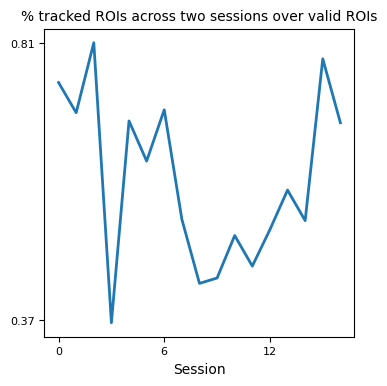

In [161]:
fig = roi_tracking_helpers.visualize_pairwise_cluster_persistence(idx_original_aligned, num_valid_neurons)
fig.savefig(os.path.join(alignment_dir, 'pairwise_cluster_persistence.png'))

#### Visualize ROIs: Ignore for now - work in progress


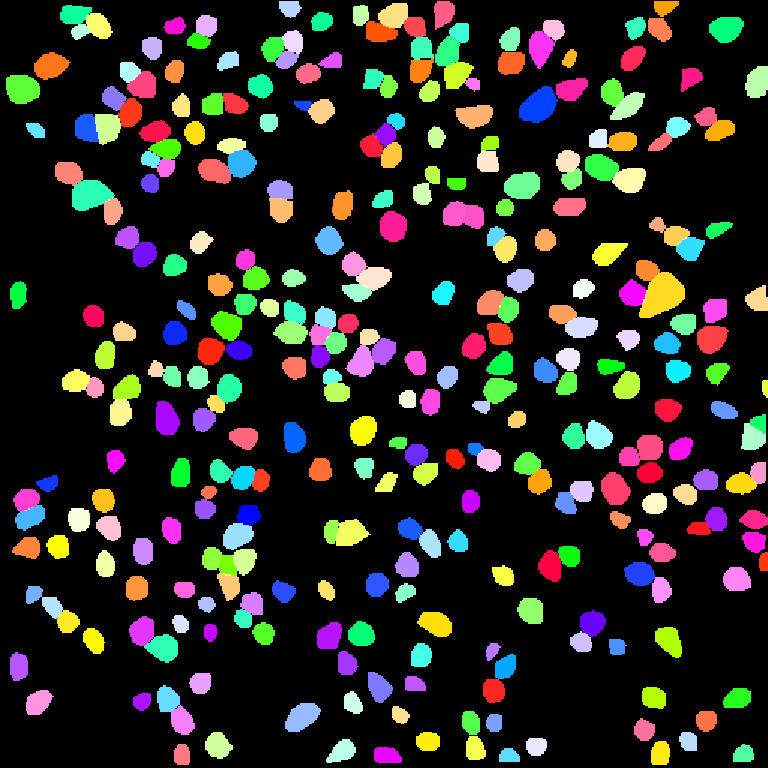

In [ ]:
# TODO Visualize selected ROIs across sessions

# # Keep neurons that have been clustered in all sessions
# idx_array = np.vstack(idx_original_aligned)  # shape: (n_sessions, n_neurons)
# valid_mask = np.all(~np.isnan(idx_array), axis=0)  # Find neurons that are not nan in all sessions
# valid_indices = np.where(valid_mask)[0]  # Get the indices that are valid across all sessions
# tracked_neuron_ids = [session[valid_indices].astype(int) for session in idx_original_aligned]

# roicat_visualize_tracked_rois(roicat_dir, roicat_data_name, sessions_to_align=sessions_to_align, tracked_neuron_ids=tracked_neuron_ids)

Visualizing neurons tuned to goal 1 in T4 T5:



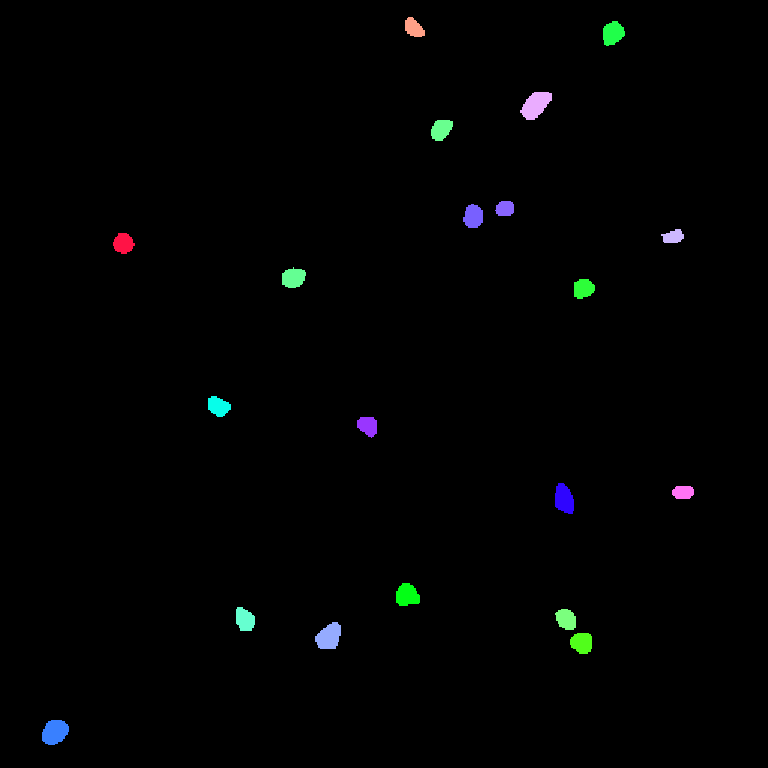

In [ ]:
# # Choose specific subset of neurons
# tracked_neuron_file = np.load(os.path.join(savepath, 'tracked_reward_tuned_neurons.npz'), allow_pickle=True)
# tracked_neuron_idx = tracked_neuron_file['tracked_reward_id_tuned_idx'][()]
# neurons_considered_sessions = tracked_neuron_file['neurons_considered_sessions']  # neurons with good signal for each session

# ABCD_goals = [1,2,3,4]
# num_sessions = len(sessions_to_align)
# # overlapping_neurons = {s: {goal: [] for goal in (ABCD_goals if protocol_nums[s] >= 5 else [1])} for s in range(num_sessions)}

# # Visualize neurons tuned to each goal in all sessions
# for goal in ABCD_goals:
#     if not all(goal in tracked_neuron_idx[s] for s in range(num_sessions)):
#         continue 

#     neuron_lists = [tracked_neuron_idx[s][goal] for s in range(num_sessions)]
#     overlapping_neurons = reduce(np.intersect1d, neuron_lists)
#     tracked_neuron_ids = [session[overlapping_neurons].astype(int) for session in neurons_considered_sessions]

#     print(f'Visualizing neurons tuned to goal {goal} in {' '.join([f'T{protocol_nums[s]}' for s in range(num_sessions)])}:')
#     roicat_visualize_tracked_rois(roicat_dir, roicat_data_name, sessions_to_align=sessions_to_align, tracked_neuron_ids=tracked_neuron_ids)